# Exercice 1.1 — Analyse exploratoire des données (EDA) sur Ames Housing

Dans ce notebook, je garde le même fil conducteur que pour l'oral :

1. **la qualité du bien** (`Overall Qual`),
2. **la surface habitable** (`Gr Liv Area`),
3. **la localisation** (`Neighborhood`).

L'idée est de montrer dès l'EDA que ces trois dimensions sont plausibles pour expliquer `SalePrice`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


## 1. Structure générale du dataset

In [2]:
print("Dimensions :", df.shape)
print("\nTypes de données :")
print(df.dtypes.value_counts())
print("\nAperçu des colonnes :")
print(df.columns.tolist()[:20])
df.info()

Dimensions : (2197, 82)

Types de données :
object     43
int64      28
float64    11
Name: count, dtype: int64

Aperçu des colonnes :
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2197 non-null   int64  
 1   PID              2197 non-null   int64  
 2   MS SubClass      2197 non-null   int64  
 3   MS Zoning        2197 non-null   object 
 4   Lot Frontage     1835 non-null   float64
 5   Lot Area         2197 non-null   int64  
 6   Street           2197 non-null   object 
 7   Alley            143 non-null    object 
 8   Lot Shape        2197 non

### Réponse — Structure du dataset

Le dataset contient **2197 lignes** et **82 colonnes**. On y trouve principalement trois types :
- des variables **qualitatives** (`object`),
- des variables **quantitatives entières** (`int64`),
- des variables **quantitatives continues** (`float64`).

Cette diversité est intéressante, car elle permet d'étudier le prix sous plusieurs angles :
- la **qualité du bien** avec `Overall Qual`,
- la **surface habitable** avec `Gr Liv Area`,
- la **localisation** avec `Neighborhood`.

Je retiens ces variables car elles sont à la fois **interprétables métier** et **utiles pour l'oral**. Par exemple, `Overall Qual` est plus pertinente que `Overall Cond` pour expliquer le prix : l'état général renseigne sur l'usure, alors que la qualité globale capte davantage le standing perçu du logement.

## 2. Valeurs manquantes

In [3]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "nb_manquants": missing_count,
    "pct_manquants": (missing_count / len(df) * 100).round(2)
}).sort_values("pct_manquants", ascending=False)

missing_table[missing_table["nb_manquants"] > 0].head(15)

,nb_manquants,pct_manquants
Pool QC,2185,99.45
Misc Feature,2117,96.36
Alley,2054,93.49
Fence,1778,80.93
Mas Vnr Type,1329,60.49
Fireplace Qu,1066,48.52
Lot Frontage,362,16.48
Garage Qual,122,5.55
Garage Yr Blt,122,5.55
Garage Cond,122,5.55


### Réponse — Valeurs manquantes

Le dataset comporte **27 colonnes avec au moins une valeur manquante**.

Les colonnes avec **plus de 50 %** de valeurs manquantes sont :
- `Pool QC`,
- `Misc Feature`,
- `Alley`,
- `Fence`,
- `Mas Vnr Type`.

Cela ne signifie pas forcément que les données sont “mauvaises”. Dans Ames Housing, beaucoup de valeurs manquantes correspondent à une **absence de caractéristique** : par exemple, ne pas avoir de piscine ou de ruelle d'accès. Il faut donc éviter d'interpréter automatiquement ces valeurs comme des erreurs.

Pour mon étude, je garde surtout des variables plus centrales pour l'explication du prix : `Overall Qual`, `Gr Liv Area`, `Neighborhood` et `SalePrice`. Ce choix est justifié car ces variables sont à la fois **peu manquantes** et **fortement liées à la valeur du bien**.

## 3. Doublons

In [4]:
duplicates = df.duplicated().sum()
print("Nombre de doublons exacts :", duplicates)

Nombre de doublons exacts : 0


### Réponse — Doublons

Je ne détecte **aucune ligne dupliquée** exacte. C'est important, car des doublons auraient pu biaiser les statistiques descriptives et les graphiques.

## 4. Sous-ensemble de variables d'intérêt

In [5]:
vars_core = ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Lot Area', 'Year Built']
df_subset = df[vars_core].copy()
df_subset.head()

,SalePrice,Overall Qual,Gr Liv Area,Neighborhood,Lot Area,Year Built
0,159000,7,1218,SawyerW,9605,2007
1,271900,7,2196,SawyerW,14684,1990
2,137500,6,1344,Timber,14375,1958
3,248500,9,1456,NridgHt,6472,2008
4,167000,7,1374,Gilbert,9734,2004


### Réponse — Choix des variables

J'ai constitué un sous-ensemble centré sur mes hypothèses :

- `SalePrice` : variable cible ;
- `Overall Qual` : proxy de la **qualité du bien** ;
- `Gr Liv Area` : mesure de la **surface habitable réelle** ;
- `Neighborhood` : variable de **localisation** ;
- `Lot Area` : variable complémentaire pour distinguer la taille du terrain de la taille habitable ;
- `Year Built` : variable de contexte sur l'ancienneté.

Je choisis `Gr Liv Area` plutôt que le simple nombre de pièces, car la surface habitable décrit mieux l'espace réellement utilisable. Je choisis aussi `Neighborhood` plutôt qu'une variable géographique plus indirecte, car elle est plus claire à défendre à l'oral.

## 5. Statistiques descriptives univariées

In [6]:
vars_5 = ['Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual']

rows = []
for var in vars_5:
    s = df[var].dropna()
    rows.append({
        'Variable': var,
        'Moyenne': s.mean(),
        'Ecart-type': s.std(),
        'Min': s.min(),
        'Q1': s.quantile(0.25),
        'Mediane': s.median(),
        'Q3': s.quantile(0.75),
        'Max': s.max(),
        'IQR': s.quantile(0.75) - s.quantile(0.25),
        'Skewness': stats.skew(s),
        'Kurtosis': stats.kurtosis(s)
    })

stats_table = pd.DataFrame(rows).round(2)
stats_table

,Variable,Moyenne,Ecart-type,Min,Q1,Mediane,Q3,Max,IQR,Skewness,Kurtosis
0,Gr Liv Area,1507.87,511.84,334,1142.0,1452.0,1762.0,5642,620.0,1.37,4.89
1,SalePrice,182376.85,81168.16,13100,130000.0,163500.0,215000.0,755000,85000.0,1.78,5.48
2,Lot Area,10268.07,7975.74,1300,7500.0,9488.0,11660.0,215245,4160.0,12.85,270.60
3,Year Built,1972.03,30.45,1872,1954.0,1975.0,2002.0,2010,48.0,-0.66,-0.41
4,Overall Qual,6.12,1.43,1,5.0,6.0,7.0,10,2.0,0.16,0.10


### Réponse — Lecture des statistiques

Quelques constats ressortent immédiatement :

- `SalePrice` est **asymétrique à droite** : la moyenne est tirée vers le haut par des biens très chers.
- `Gr Liv Area` est aussi **étalée à droite**, ce qui est classique en immobilier : il existe peu de maisons extrêmement grandes, mais elles influencent fortement la moyenne.
- `Lot Area` est la variable la plus extrême, avec une **forte asymétrie** et des valeurs très dispersées.
- `Overall Qual` est plus équilibrée, avec une concentration autour des niveaux intermédiaires.
- `Year Built` est légèrement asymétrique à gauche, ce qui traduit une présence importante de logements récents dans certaines périodes.

Ces statistiques soutiennent déjà mon hypothèse : le prix ne dépend probablement pas seulement de la taille du terrain, mais davantage de la **qualité du bien** et de la **surface habitable**.

## 6. Visualisations univariées

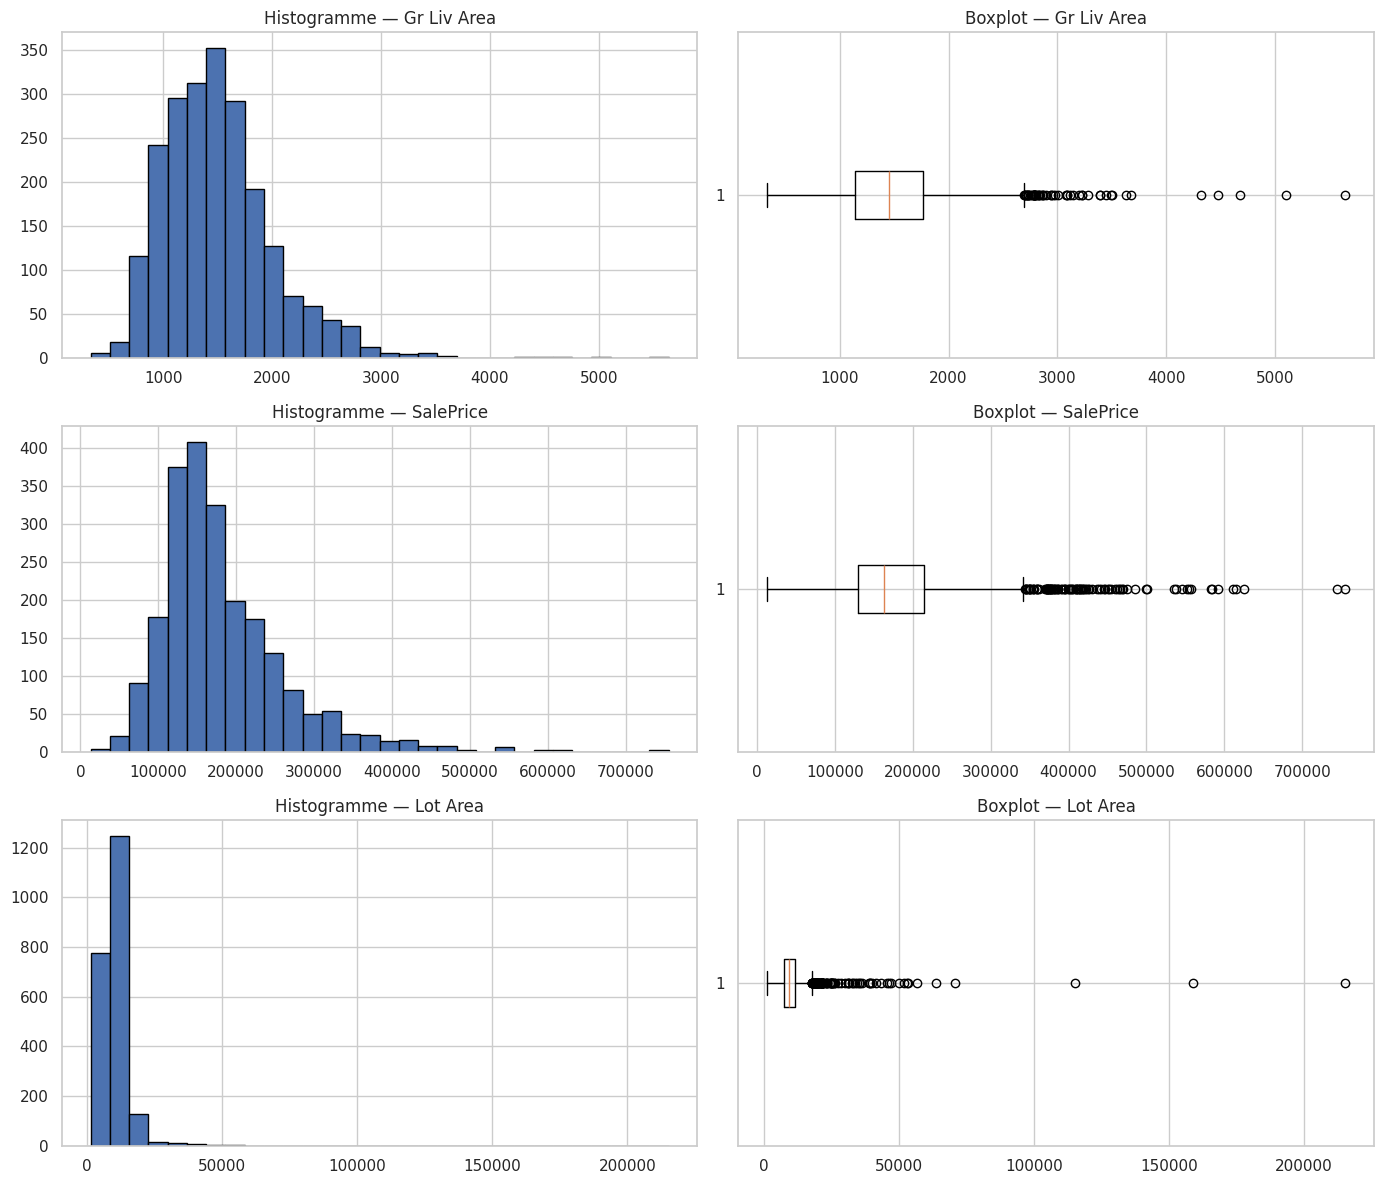

In [7]:
continuous_vars = ['Gr Liv Area', 'SalePrice', 'Lot Area']
fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(14, 12))

for i, var in enumerate(continuous_vars):
    s = df[var].dropna() if 'df' in globals() else df_subset[var].dropna()
    axes[i,0].hist(s, bins=30, edgecolor='black')
    axes[i,0].set_title(f'Histogramme — {var}')
    axes[i,1].boxplot(s, vert=False)
    axes[i,1].set_title(f'Boxplot — {var}')

plt.tight_layout()
plt.show()

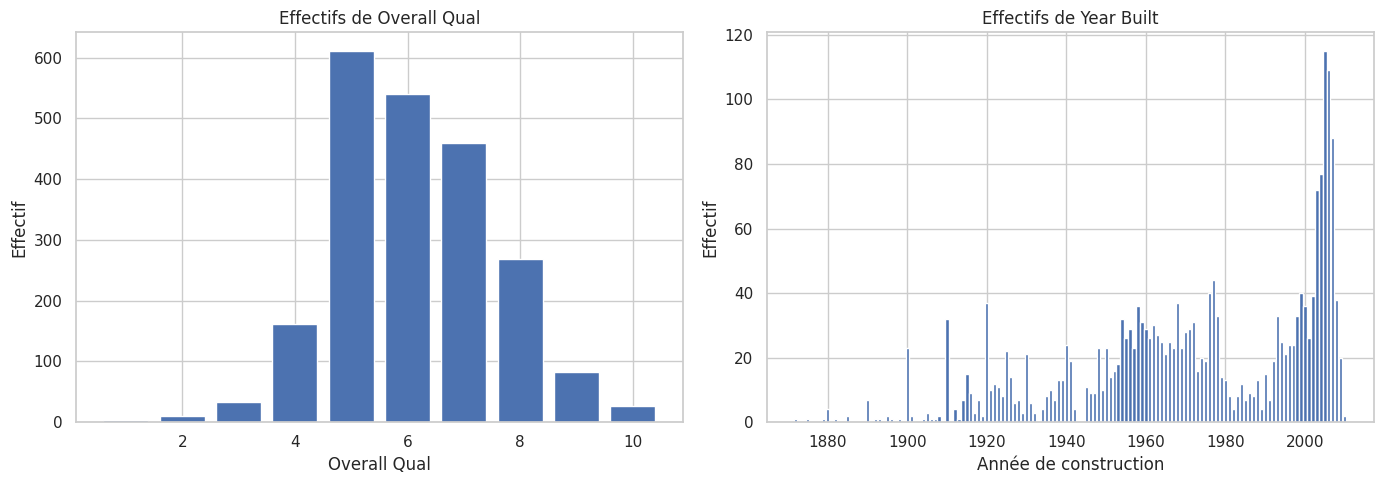

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qual_counts = df_subset['Overall Qual'].value_counts().sort_index()
axes[0].bar(qual_counts.index, qual_counts.values)
axes[0].set_title('Effectifs de Overall Qual')
axes[0].set_xlabel('Overall Qual')
axes[0].set_ylabel('Effectif')

year_counts = df_subset['Year Built'].value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values)
axes[1].set_title('Effectifs de Year Built')
axes[1].set_xlabel('Année de construction')
axes[1].set_ylabel('Effectif')

plt.tight_layout()
plt.show()

### Réponse — Hypothèses pour les graphiques

**Hypothèse pour `Gr Liv Area` :** je m'attends à une distribution étalée à droite, car la majorité des maisons ont une surface “classique”, tandis que quelques biens très grands forment une queue de distribution.

**Hypothèse pour `SalePrice` :** je m'attends à une asymétrie à droite pour la même raison : quelques maisons haut de gamme augmentent fortement le prix maximal.

**Hypothèse pour `Lot Area` :** je m'attends à une dispersion encore plus forte que pour la surface habitable, car certains terrains sont exceptionnellement grands.

**Hypothèse pour `Overall Qual` :** je m'attends à une concentration sur les notes intermédiaires, car le marché est généralement dominé par des logements de qualité moyenne à bonne plutôt que par les extrêmes.

Ces graphiques servent à justifier le fait que la **qualité**, la **surface habitable** et ensuite la **localisation** sont de meilleures pistes d'analyse du prix que des variables plus marginales.

## 7. Détection des outliers : IQR vs z-score modifié

In [9]:
def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return lower, upper, mask

def modified_z_outliers(series, threshold=3.5):
    s = series.dropna()
    med = s.median()
    mad = np.median(np.abs(s - med))
    mod_z = 0.6745 * (series - med) / mad
    mask = np.abs(mod_z) > threshold
    return med, mad, mod_z, mask

summary = []
for var in ['SalePrice', 'Lot Area']:
    low, up, mask_iqr = iqr_outliers(df[var])
    med, mad, modz, mask_mod = modified_z_outliers(df[var])
    summary.append({
        'Variable': var,
        'Outliers_IQR': int(mask_iqr.sum()),
        'Pct_IQR': round(mask_iqr.mean()*100, 2),
        'Outliers_ModZ': int(mask_mod.sum()),
        'Pct_ModZ': round(mask_mod.mean()*100, 2)
    })

outliers_table = pd.DataFrame(summary)
outliers_table

,Variable,Outliers_IQR,Pct_IQR,Outliers_ModZ,Pct_ModZ
0,SalePrice,97,4.42,81,3.69
1,Lot Area,99,4.51,68,3.10


### Réponse — Comparaison des méthodes d'outliers

Les deux méthodes ne détectent pas exactement les mêmes observations. C'est normal :
- la méthode **IQR** repose sur les quartiles ;
- le **z-score modifié** repose sur la médiane et le MAD.

Sur des distributions très asymétriques comme `Lot Area`, les résultats peuvent diverger davantage. Le z-score modifié est souvent plus robuste, alors que la méthode IQR est très pratique pour une première lecture visuelle, surtout en lien avec les boxplots.

Pour l'oral, cela montre qu'il faut rester prudent : un point extrême n'est pas forcément une “erreur”, il peut aussi correspondre à une propriété réellement atypique.

## 8. Hypothèses métier

### Réponse — Trois hypothèses testables

1. **Qualité du bien → prix**  
   Plus `Overall Qual` est élevée, plus `SalePrice` augmente.  
   Je choisis cette variable car elle résume mieux le standing global du logement que `Overall Cond`.

2. **Surface habitable → prix**  
   Plus `Gr Liv Area` est grande, plus `SalePrice` tend à augmenter.  
   Je choisis cette variable plutôt qu'un simple nombre de pièces, car elle mesure directement l'espace réellement habitable.

3. **Localisation → prix**  
   Le prix varie significativement selon `Neighborhood`.  
   Je choisis `Neighborhood` car l'emplacement est une dimension centrale du marché immobilier et permet de montrer qu'une maison ne vaut pas seulement par ses caractéristiques internes.

Ces hypothèses guideront la suite des visualisations et des analyses multivariées.